In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import alpha
from IPython.display import display, clear_output

_Создадим функцию с одним признаком._

In [3]:
def func(x):
    return x**3 - 6*x**2 - 15*x + 10

_Обозначим точки для x. И соответствующие им значения y._

In [4]:
x_start = np.linspace(-5, 10, 30)
y = func(x_start)


#### **Инициализируем функцию создания нового холста с нашими настройками.**

_Создадим холст. Через **sublots**, чтобы использовать только ту часть холста, которую мы позже передадим в функцию._

_Сохраним координаты этой части холста в переменной **ax**. Чтобы после функция рисовала на том же графике._

_Также зададим  размер холста._

_Обозначим на нем функцию. Зададим её прозрачность и укажем, что она лежит на первом слое **zorder**._

_И подпишем оси._

In [5]:
def holst():
    fig, ax = plt.subplots(figsize=(10, 10), facecolor='#b5b8b1') #холст
    ax.plot(x_start, y, color='#79553d', alpha=0.5, zorder=1) #функция
    ax.set_xlabel('x', color='#79553d', fontsize=20) #имя для X
    ax.set_ylabel('f', color='#79553d', fontsize=20) #имя для Y
    ax.legend(['функция, по которой мы спускаемся'])
    return fig, ax

(<Figure size 1000x1000 with 1 Axes>, <Axes: xlabel='x', ylabel='f'>)

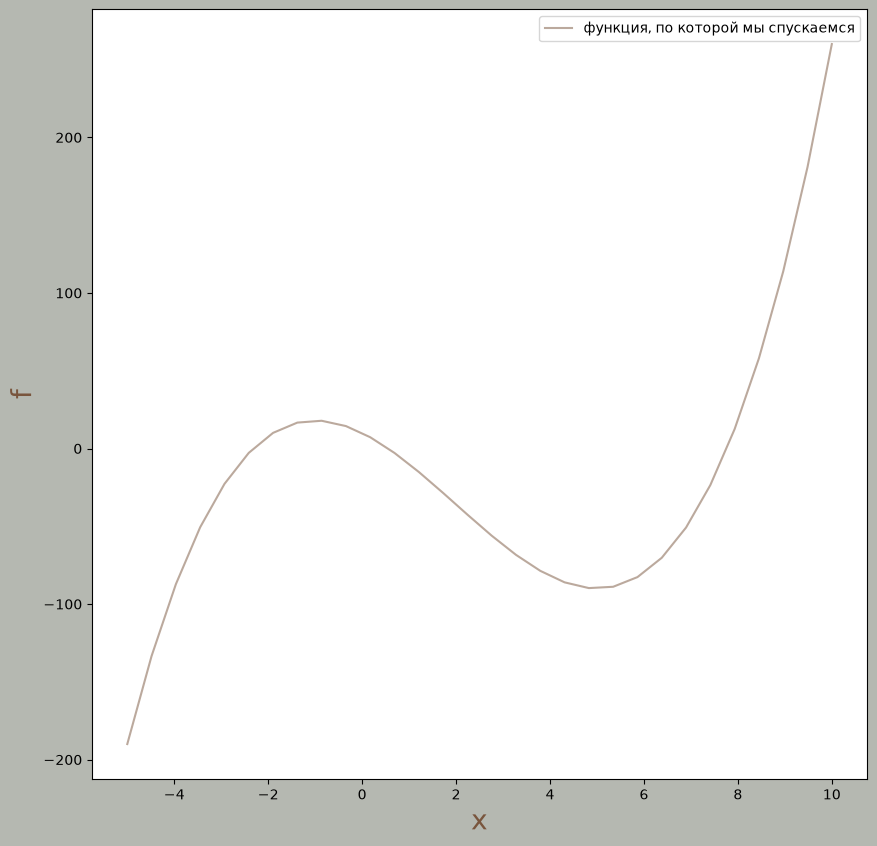

In [6]:
holst()

#### **Градиентный спуск.**

_Поиск производной от нашей функции._

In [7]:
def func_derivative(x):
    return 3 * x**2 - 12 * x - 15

_Функция для реализации и отрисовки одного шага градиентного спуска._

In [8]:
def step(ax, x_start, lr):
    #изобразим начальную точку
    ax.scatter(x_start, func(x_start), color='#8ccb5e', s=100, zorder=2, alpha=0.5)
    #вычислим градиент
    grad = lr * func_derivative(x_start)
    #сделаем шаг в обратную сторону
    x_next = x_start - grad
    if abs(x_next) > 10:
        return None
    #изобразим новую точку
    ax.scatter(x_next, func(x_next), color='#fbceb1', s=100, zorder=2)
    #изобразим путь
    ax.plot([x_start, x_next], [func(x_start), func(x_next)], color='#cd5c5c')
    #вернем следующую точку, чтобы после она стала стартом

    return x_next

_Функция для реализации и визуализации._

In [15]:
def descent_and_plot(x_start=6, lr=0.01, threshold=0.0001):
    #-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-
    #создадим новое полотно и сделаем один шаг, для нахождения первого x_next
    fig, ax = holst()
    ax.scatter(x_start, func(x_start), color='#cd5c5c', zorder=4, alpha=1, s=100)
    x_next = step(ax, x_start, lr)
    #-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-
    while abs(x_start - x_next) > threshold:
        x_start = x_next
        x_next = step(ax, x_start, lr)
        if x_next is None:
            break
    #
    ax.legend(['функция, в которой ищем минимум', 'начальная точка', 'конечная точка спуска'])
    plt.show() #завершим работу с текущей фигурой
    print(f'точка в конце спуска: {x_next}')

_Вызовем функцию с подходящими параметрами._

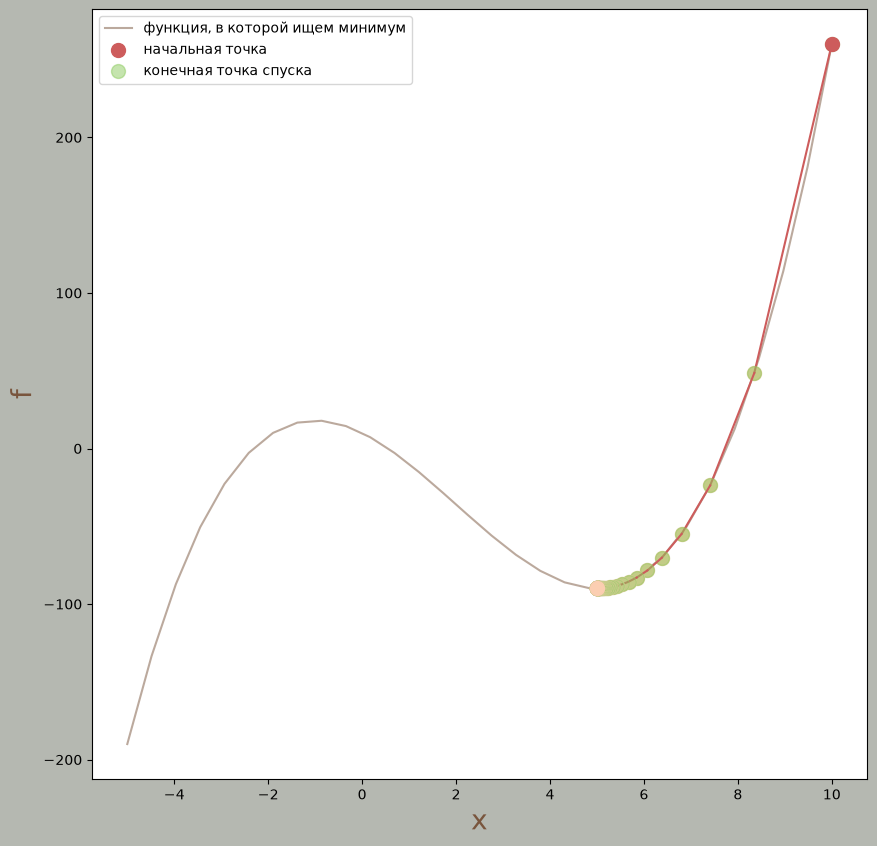

точка в конце спуска: 5.000382502344409


In [16]:
descent_and_plot(x_start=10)

_Вызовем функцию с маленькой скоростью обучения._

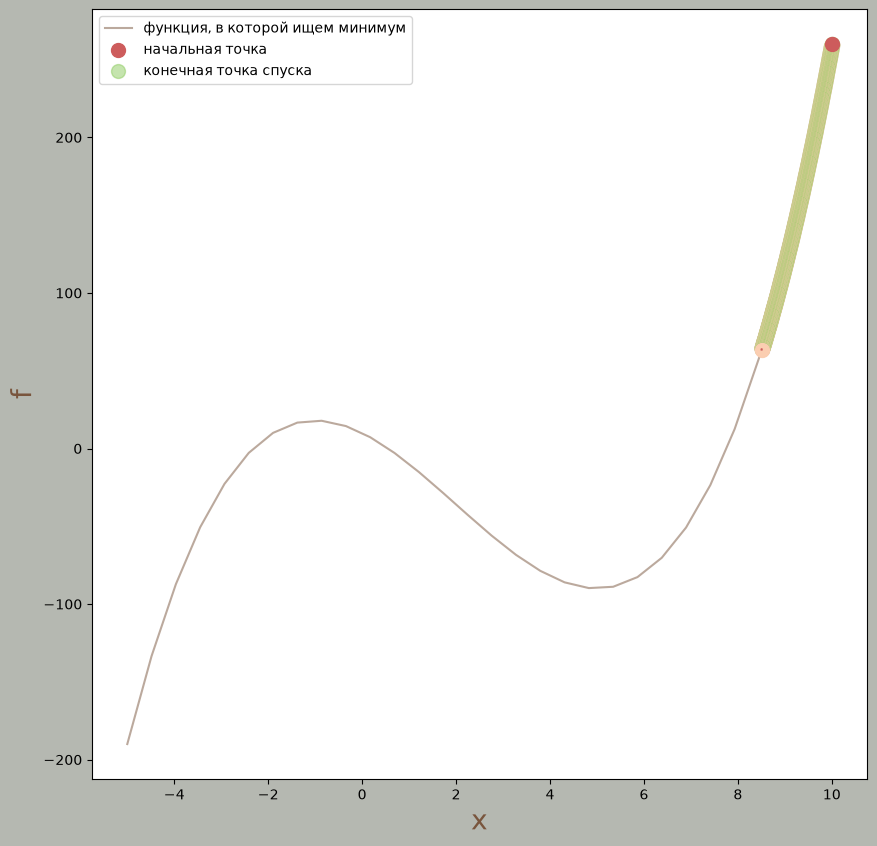

точка в конце спуска: 8.504805472225721


In [17]:
descent_and_plot(x_start = 10, lr=0.00001, threshold=0.001)

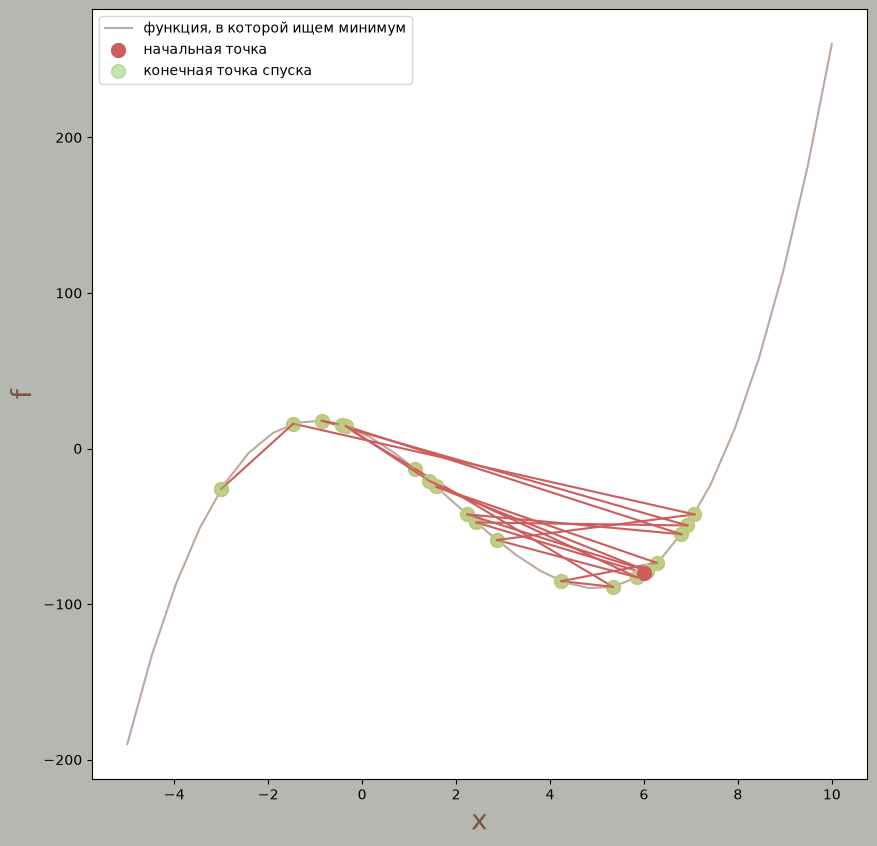

точка в конце спуска: None


In [18]:
descent_and_plot(lr=0.17)